# Temporal-Difference Control: SARSA vs. Q-Learning on CliffWalking

This portfolio notebook rebuilds a self-contained, modern Gymnasium notebook.

The supplied project contains:

- a random agent,
- tabular SARSA,
- tabular Q-learning,
- saved SARSA and Q-learning Q-tables,
- an evaluator,
- and OpenCV visualization code.

The original algorithm settings are preserved:

$$
\boxed{\epsilon=0.1}
$$

$$
\boxed{\alpha=0.1}
$$

$$
\boxed{\gamma=0.9}
$$

$$
\boxed{\text{episodes}=500}
$$

The notebook adds detailed explanations, manual calculations, reproducible training, learning curves, convergence diagnostics, Q-table inspection, policy visualization, path analysis, evaluation, saved-table comparison, and animation.

## 1. CliffWalking problem

CliffWalking is a $4\times12$ grid-world control problem.

The agent starts at the lower-left corner and must reach the lower-right goal.

The cells between the start and goal on the bottom row form the cliff.

Conceptually:

```text
.  .  .  .  .  .  .  .  .  .  .  .
.  .  .  .  .  .  .  .  .  .  .  .
.  .  .  .  .  .  .  .  .  .  .  .
S  C  C  C  C  C  C  C  C  C  C  G
```

where:

- `S` = start,
- `C` = cliff,
- `G` = goal.

The source project uses the standard deterministic CliffWalking environment.

## 2. State space

There are 48 encoded states:

$$
\boxed{
|\mathcal S|=4\times12=48
}
$$

A grid location $(r,c)$ is flattened as:

$$
\boxed{
s=12r+c
}
$$

For example, the start location is:

$$
(r,c)=(3,0)
$$

so:

$$
\boxed{
s=3(12)+0=36.
}
$$

The goal is state:

$$
\boxed{47}.
$$

## 3. Action space

The environment has four discrete actions:

| Action | Meaning |
|---:|---|
| 0 | Up |
| 1 | Right |
| 2 | Down |
| 3 | Left |

Therefore the action-value table has shape:

$$
\boxed{
48\times4
}
$$

and each entry represents:

$$
\boxed{
Q(s,a)
}
$$

the estimated return obtained by taking action $a$ in state $s$ and then following the learning policy.

## 4. Reward function

The notebook uses the environment's original CliffWalking reward.

For an ordinary transition:

$$
\boxed{R_{t+1}=-1}
$$

If the agent steps into the cliff:

$$
\boxed{R_{t+1}=-100}
$$

and the agent is returned to the starting state.

The episode terminates when the goal is reached.

No custom reward shaping is added.

## 5. Why compare SARSA and Q-learning?

Both algorithms are temporal-difference control methods.

They learn directly from experience without requiring a known transition model.

The important difference is the target they use.

### SARSA

SARSA uses the action that the behavior policy actually selects:

$$
\boxed{
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma Q(S_{t+1},A_{t+1})
-
Q(S_t,A_t)
\right]
}
$$

### Q-learning

Q-learning uses the greedy action value at the next state:

$$
\boxed{
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma
\max_a Q(S_{t+1},a)
-
Q(S_t,A_t)
\right]
}
$$

Therefore:

$$
\boxed{\text{SARSA = on-policy}}
$$

and:

$$
\boxed{\text{Q-learning = off-policy}}.
$$

## 6. Source-faithful epsilon-greedy policy

The supplied scripts first choose:

```python
np.argmax(q_table[state])
```

and replace that action with a uniformly random action with probability:

$$
\boxed{\epsilon=0.1}.
$$

Thus:

$$
P(\text{explore})=0.1
$$

and:

$$
P(\text{greedy branch})=0.9.
$$

Because NumPy's `argmax` returns the first maximum, all-zero Q-values initially favor action `0` (Up) whenever the policy does not explore.

This notebook preserves that tie-breaking behavior.

## 7. Manual calculation 1: the first ordinary update

Suppose the Q-table is initially zero.

The agent starts at:

$$
S_t=36.
$$

Assume it takes action:

$$
A_t=0
$$

which means **Up**.

The environment gives:

$$
R_{t+1}=-1.
$$

Initially every next-state Q-value is zero.

For both SARSA and Q-learning at this first transition:

$$
\text{target}
=
-1+0.9(0)
=
-1.
$$

The TD error is:

$$
\delta_t
=
-1-0
=
-1.
$$

With:

$$
\alpha=0.1,
$$

the update is:

$$
Q(36,0)
=
0+0.1(-1)
=
\boxed{-0.1}.
$$

## 8. Manual calculation 2: stepping into the cliff

Suppose the agent is at the starting state:

$$
S_t=36
$$

and chooses **Right**:

$$
A_t=1.
$$

That enters the cliff, so:

$$
R_{t+1}=-100
$$

and the environment returns the agent to the start.

If all relevant Q-values are still zero:

$$
\text{target}
=
-100+0.9(0)
=
-100.
$$

Therefore:

$$
Q(36,1)
=
0+0.1(-100)
=
\boxed{-10}.
$$

The large negative update makes the agent learn very quickly that stepping directly into the cliff is undesirable.

## 9. Manual calculation 3: SARSA vs. Q-learning

Assume:

$$
Q(S_t,A_t)=-5.
$$

After the transition:

$$
R_{t+1}=-1.
$$

Suppose the next-state action values are:

$$
Q(S_{t+1},:)
=
[-4,-3,-5,-4.5].
$$

### Q-learning

Q-learning selects the largest next-state value:

$$
\max_a Q(S_{t+1},a)=-3.
$$

Therefore:

$$
Y_t^{QL}
=
-1+0.9(-3)
=
-3.7.
$$

The TD error is:

$$
\delta_t^{QL}
=
-3.7-(-5)
=
1.3.
$$

The new value is:

$$
Q_{\text{new}}
=
-5+0.1(1.3)
=
\boxed{-4.87}.
$$

### SARSA

Suppose the epsilon-greedy behavior policy actually selects an action with:

$$
Q(S_{t+1},A_{t+1})=-4.5.
$$

Then:

$$
Y_t^{SARSA}
=
-1+0.9(-4.5)
=
-5.05.
$$

The TD error is:

$$
\delta_t^{SARSA}
=
-5.05-(-5)
=
-0.05.
$$

The update becomes:

$$
Q_{\text{new}}
=
-5+0.1(-0.05)
=
\boxed{-5.005}.
$$

The difference comes entirely from the next-state value used in the target.

## 10. Expected behavior on the cliff

Q-learning learns toward the greedy optimal policy.

In deterministic CliffWalking, that often means learning the shortest safe route immediately above the cliff.

SARSA learns the value of its epsilon-greedy behavior policy.

Because the training policy continues to explore, states close to the cliff can be risky: an exploratory move may cause a $-100$ penalty.

As a result, SARSA often learns a safer route farther from the cliff during training.

This is the classic reason CliffWalking is useful for comparing on-policy and off-policy TD control.

## 11. Colab setup

In [1]:
%pip -q install gymnasium imageio imageio-ffmpeg

In [2]:
import os
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import gymnasium as gym
from IPython.display import display, Video
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 3)
print("Gymnasium version:", gym.__version__)

Gymnasium version: 1.3.0


## 12. Environment compatibility

The supplied source used:

```python
gym.make("CliffWalking-v0")
```

The current Gymnasium documentation uses `CliffWalking-v1`.

Version `v1` adds an optional slippery mode.

To preserve the deterministic source problem, this notebook uses:

```python
gym.make("CliffWalking-v1", is_slippery=False)
```

The state space, action space, cliff structure, and deterministic reward problem remain the same.

In [3]:
ENV_ID = "CliffWalking-v1"
env = gym.make(ENV_ID, is_slippery=False)
state, info = env.reset(seed=SEED)
print("Initial state:", state)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
env.close()

Initial state: 36
Observation space: Discrete(48)
Action space: Discrete(4)


## 13. Hyperparameters from the supplied source

In [4]:
EPSILON = 0.1
ALPHA = 0.1
GAMMA = 0.9
NUM_EPISODES = 500
NUM_STATES = 48
NUM_ACTIONS = 4
ACTION_NAMES = ["Up", "Right", "Down", "Left"]
ACTION_SYMBOLS = ["↑", "→", "↓", "←"]
START_STATE = 36
GOAL_STATE = 47
print("Epsilon:", EPSILON)
print("Alpha:", ALPHA)
print("Gamma:", GAMMA)
print("Episodes:", NUM_EPISODES)

Epsilon: 0.1
Alpha: 0.1
Gamma: 0.9
Episodes: 500


## 14. Epsilon-greedy policy matching the source

In [5]:
def epsilon_greedy(q_table, state, epsilon, rng):
    action = int(np.argmax(q_table[state]))
    if rng.random() <= epsilon:
        action = int(rng.integers(low=0, high=NUM_ACTIONS))
    return action

## 15. Random-agent baseline

The supplied project includes a purely random agent.

A random baseline helps answer:

> Did learning actually produce a better policy than random behavior?

The baseline below uses the same CliffWalking reward and terminates at the goal.

A safety step limit is included only to prevent an unusually long random episode from running indefinitely.

In [6]:
def run_random_agent(episodes=100, seed=SEED, max_steps=5000):
    env = gym.make(ENV_ID, is_slippery=False)
    rng = np.random.default_rng(seed)
    rewards = []
    lengths = []
    cliff_falls = []
    for episode in range(episodes):
        state, info = env.reset(seed=seed + episode)
        total_reward = 0.0
        episode_length = 0
        episode_cliffs = 0
        done = False
        while not done and episode_length < max_steps:
            action = int(rng.integers(low=0, high=NUM_ACTIONS))
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += reward
            episode_length += 1
            if reward == -100:
                episode_cliffs += 1
            state = next_state
        rewards.append(total_reward)
        lengths.append(episode_length)
        cliff_falls.append(episode_cliffs)
    env.close()
    return pd.DataFrame({"episode": np.arange(1, episodes + 1), "reward": rewards, "length": lengths, "cliff_falls": cliff_falls})

random_history = run_random_agent()
display(random_history.head())
print("Random mean reward:", random_history["reward"].mean())
print("Random mean episode length:", random_history["length"].mean())
print("Random mean cliff falls:", random_history["cliff_falls"].mean())

,episode,reward,length,cliff_falls
0,1,-53906.0,5000,494
1,2,-53411.0,5000,489
2,3,-7737.0,807,70
3,4,-34958.0,3575,317
4,5,-31369.0,2956,287


Random mean reward: -33980.24
Random mean episode length: 3357.56
Random mean cliff falls: 309.32


## 16. Source-faithful SARSA

In [7]:
def train_sarsa(num_episodes=NUM_EPISODES, epsilon=EPSILON, alpha=ALPHA, gamma=GAMMA, seed=SEED):
    env = gym.make(ENV_ID, is_slippery=False)
    rng = np.random.default_rng(seed)
    q_table = np.zeros((NUM_STATES, NUM_ACTIONS), dtype=np.float64)
    rewards = []
    lengths = []
    cliff_falls = []
    q_change = []
    for episode in range(num_episodes):
        q_before = q_table.copy()
        state, info = env.reset(seed=seed + episode)
        action = epsilon_greedy(q_table, state, epsilon, rng)
        total_reward = 0.0
        episode_length = 0
        episode_cliffs = 0
        done = False
        while not done:
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_action = epsilon_greedy(q_table, next_state, epsilon, rng)
            td_target = reward + gamma * q_table[next_state, next_action]
            td_error = td_target - q_table[state, action]
            q_table[state, action] = q_table[state, action] + alpha * td_error
            state = next_state
            action = next_action
            total_reward += reward
            episode_length += 1
            if reward == -100:
                episode_cliffs += 1
        rewards.append(total_reward)
        lengths.append(episode_length)
        cliff_falls.append(episode_cliffs)
        q_change.append(np.max(np.abs(q_table - q_before)))
    env.close()
    history = pd.DataFrame({"episode": np.arange(1, num_episodes + 1), "reward": rewards, "length": lengths, "cliff_falls": cliff_falls, "max_q_change": q_change})
    return q_table, history

## 17. Source-faithful Q-learning

In [8]:
def train_q_learning(num_episodes=NUM_EPISODES, epsilon=EPSILON, alpha=ALPHA, gamma=GAMMA, seed=SEED):
    env = gym.make(ENV_ID, is_slippery=False)
    rng = np.random.default_rng(seed)
    q_table = np.zeros((NUM_STATES, NUM_ACTIONS), dtype=np.float64)
    rewards = []
    lengths = []
    cliff_falls = []
    q_change = []
    for episode in range(num_episodes):
        q_before = q_table.copy()
        state, info = env.reset(seed=seed + episode)
        total_reward = 0.0
        episode_length = 0
        episode_cliffs = 0
        done = False
        while not done:
            action = epsilon_greedy(q_table, state, epsilon, rng)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_action = epsilon_greedy(q_table, next_state, 0.0, rng)
            td_target = reward + gamma * q_table[next_state, next_action]
            td_error = td_target - q_table[state, action]
            q_table[state, action] = q_table[state, action] + alpha * td_error
            state = next_state
            total_reward += reward
            episode_length += 1
            if reward == -100:
                episode_cliffs += 1
        rewards.append(total_reward)
        lengths.append(episode_length)
        cliff_falls.append(episode_cliffs)
        q_change.append(np.max(np.abs(q_table - q_before)))
    env.close()
    history = pd.DataFrame({"episode": np.arange(1, num_episodes + 1), "reward": rewards, "length": lengths, "cliff_falls": cliff_falls, "max_q_change": q_change})
    return q_table, history

## 18. Train both algorithms

In [9]:
sarsa_q_table, sarsa_history = train_sarsa()
q_learning_q_table, q_learning_history = train_q_learning()
print("SARSA Q-table shape:", sarsa_q_table.shape)
print("Q-learning Q-table shape:", q_learning_q_table.shape)

SARSA Q-table shape: (48, 4)
Q-learning Q-table shape: (48, 4)


## 19. Training rewards: actual episode reward

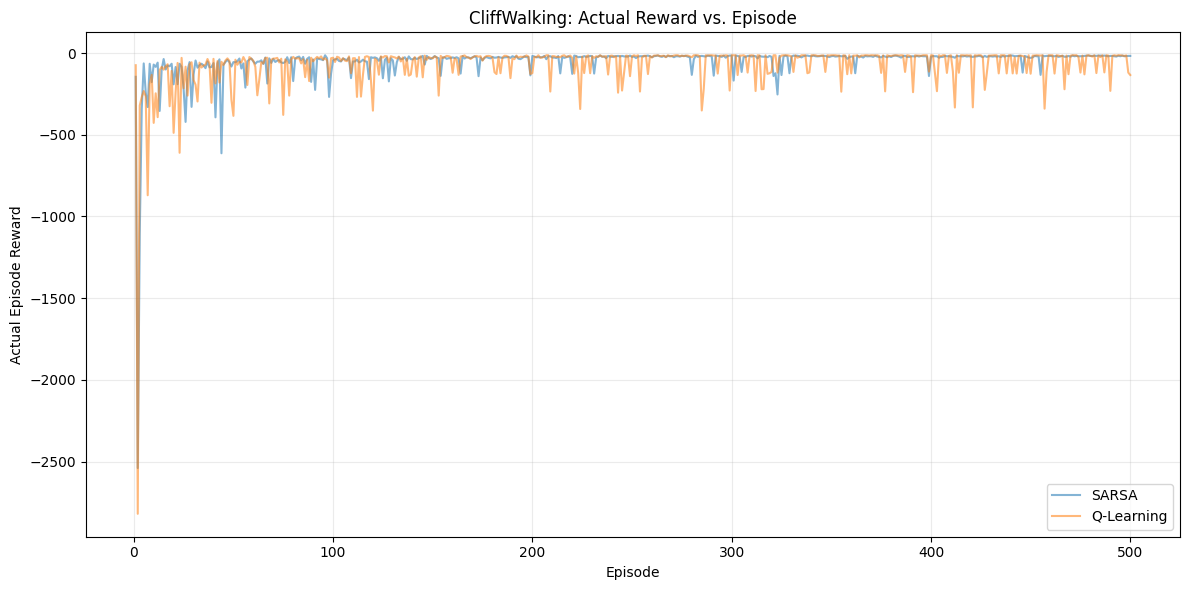

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(sarsa_history["episode"], sarsa_history["reward"], alpha=0.55, label="SARSA")
plt.plot(q_learning_history["episode"], q_learning_history["reward"], alpha=0.55, label="Q-Learning")
plt.xlabel("Episode")
plt.ylabel("Actual Episode Reward")
plt.title("CliffWalking: Actual Reward vs. Episode")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 20. Reward trend with moving average

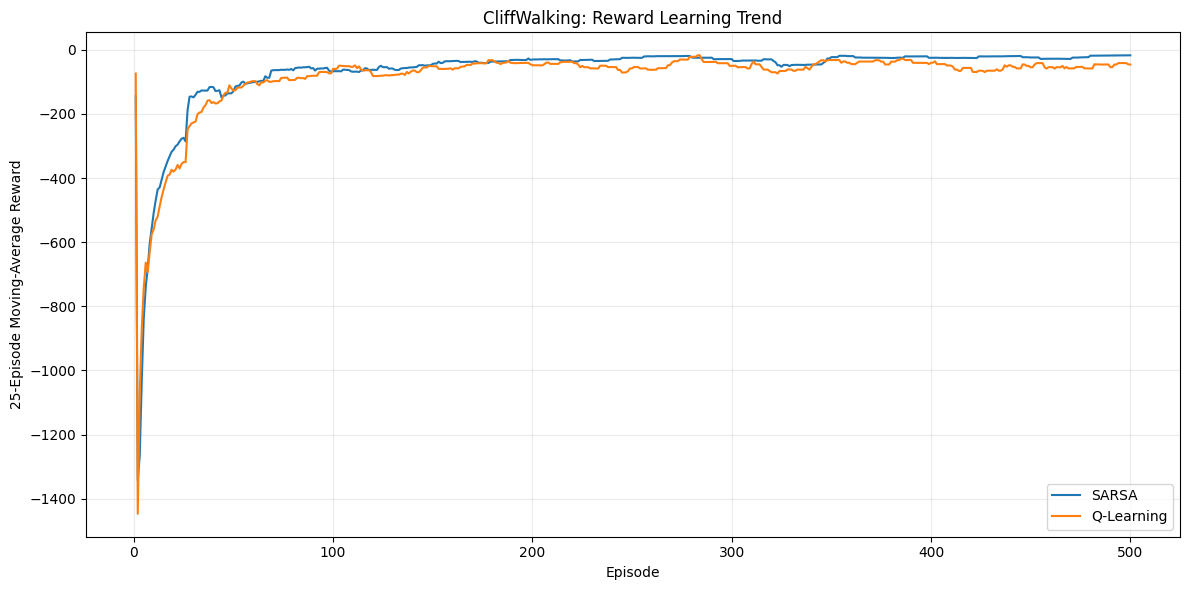

In [11]:
WINDOW = 25
sarsa_reward_ma = sarsa_history["reward"].rolling(WINDOW, min_periods=1).mean()
q_learning_reward_ma = q_learning_history["reward"].rolling(WINDOW, min_periods=1).mean()
plt.figure(figsize=(12, 6))
plt.plot(sarsa_history["episode"], sarsa_reward_ma, label="SARSA")
plt.plot(q_learning_history["episode"], q_learning_reward_ma, label="Q-Learning")
plt.xlabel("Episode")
plt.ylabel(f"{WINDOW}-Episode Moving-Average Reward")
plt.title("CliffWalking: Reward Learning Trend")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 21. Episode length

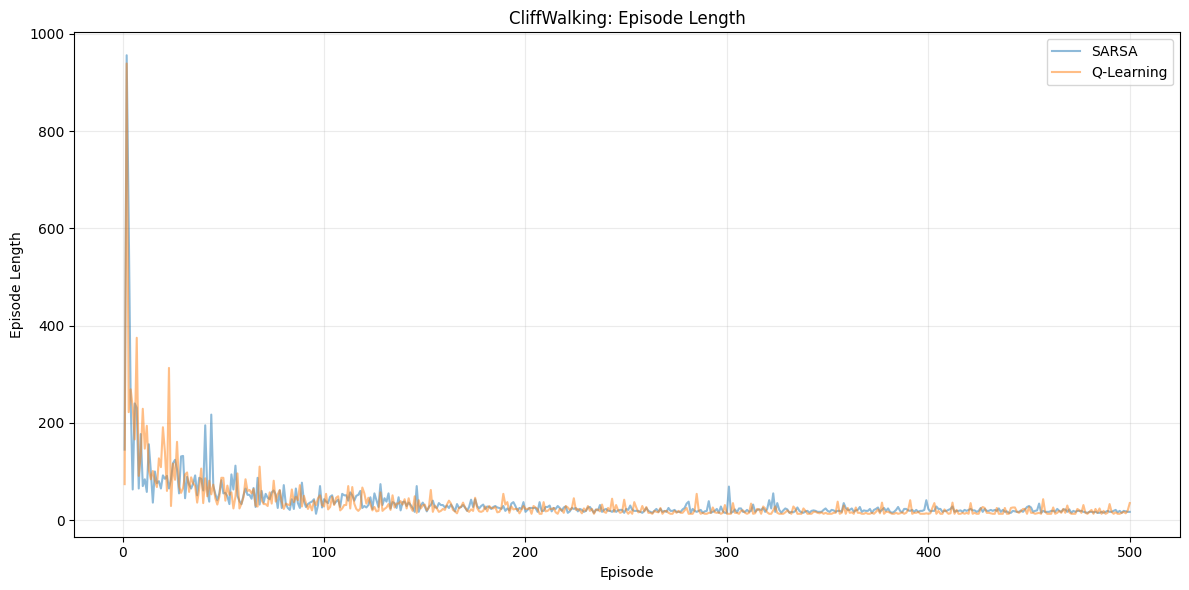

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(sarsa_history["episode"], sarsa_history["length"], alpha=0.5, label="SARSA")
plt.plot(q_learning_history["episode"], q_learning_history["length"], alpha=0.5, label="Q-Learning")
plt.xlabel("Episode")
plt.ylabel("Episode Length")
plt.title("CliffWalking: Episode Length")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 22. Cliff falls during training

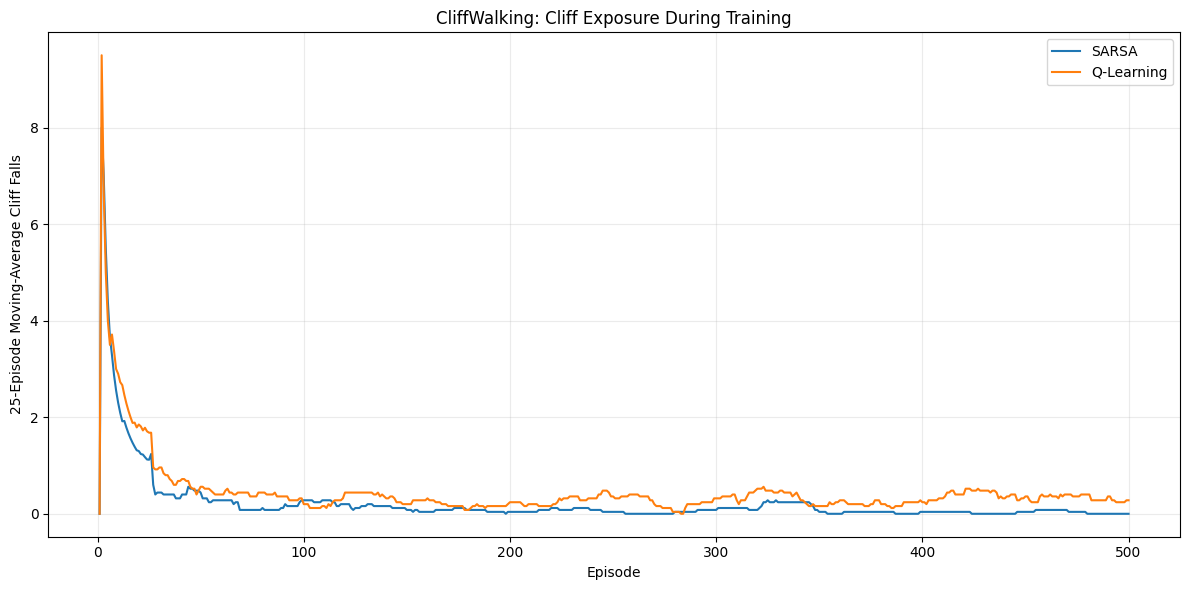

In [13]:
sarsa_cliff_ma = sarsa_history["cliff_falls"].rolling(WINDOW, min_periods=1).mean()
q_learning_cliff_ma = q_learning_history["cliff_falls"].rolling(WINDOW, min_periods=1).mean()
plt.figure(figsize=(12, 6))
plt.plot(sarsa_history["episode"], sarsa_cliff_ma, label="SARSA")
plt.plot(q_learning_history["episode"], q_learning_cliff_ma, label="Q-Learning")
plt.xlabel("Episode")
plt.ylabel(f"{WINDOW}-Episode Moving-Average Cliff Falls")
plt.title("CliffWalking: Cliff Exposure During Training")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 23. Convergence diagnostic

For each episode, the notebook stores:

$$
\boxed{
\max_{s,a}
|
Q_{\text{after}}(s,a)-Q_{\text{before}}(s,a)
|
}
$$

A decreasing value means the Q-table is changing less from one episode to the next.

Because training keeps a constant:

$$
\epsilon=0.1,
$$

exploratory transitions continue throughout training, so the curve need not become perfectly zero.

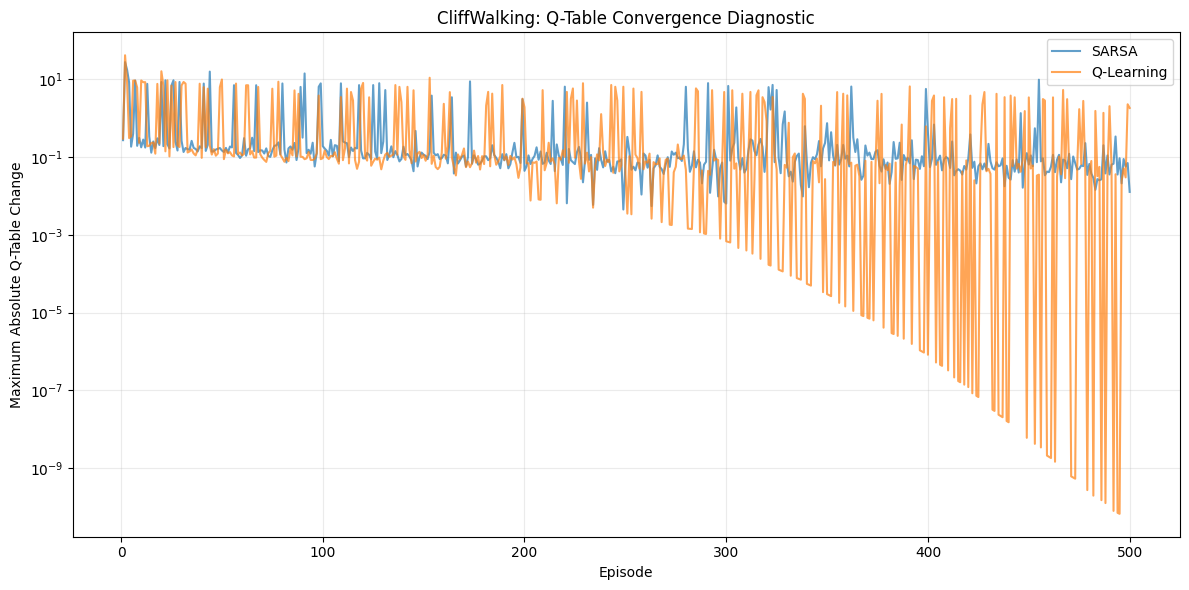

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(sarsa_history["episode"], sarsa_history["max_q_change"], alpha=0.7, label="SARSA")
plt.plot(q_learning_history["episode"], q_learning_history["max_q_change"], alpha=0.7, label="Q-Learning")
plt.xlabel("Episode")
plt.ylabel("Maximum Absolute Q-Table Change")
plt.title("CliffWalking: Q-Table Convergence Diagnostic")
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 24. Final SARSA Q-table

In [15]:
sarsa_q_df = pd.DataFrame(sarsa_q_table, columns=ACTION_NAMES)
sarsa_q_df.index.name = "State"
display(sarsa_q_df)

,Up,Right,Down,Left
State,,,,
0,-7.617,-7.583,-7.579,-7.599
1,-7.403,-7.369,-7.378,-7.379
2,-7.139,-7.125,-7.122,-7.130
3,-6.884,-6.844,-6.873,-6.910
4,-6.565,-6.526,-6.543,-6.628
5,-6.206,-6.168,-6.170,-6.264
6,-5.771,-5.764,-5.797,-5.770
7,-5.328,-5.318,-5.333,-5.386
8,-4.890,-4.818,-4.831,-4.865


## 25. Final Q-learning Q-table

In [16]:
q_learning_q_df = pd.DataFrame(q_learning_q_table, columns=ACTION_NAMES)
q_learning_q_df.index.name = "State"
display(q_learning_q_df)

,Up,Right,Down,Left
State,,,,
0,-6.906,-6.901,-6.933,-6.898
1,-6.746,-6.728,-6.749,-6.768
2,-6.541,-6.503,-6.509,-6.513
3,-6.216,-6.210,-6.248,-6.286
4,-5.896,-5.895,-5.942,-5.915
5,-5.594,-5.541,-5.581,-5.548
6,-5.186,-5.174,-5.189,-5.211
7,-4.787,-4.737,-4.763,-4.813
8,-4.280,-4.272,-4.281,-4.392


## 26. Greedy policy extracted from each Q-table

After training, the greedy action is:

$$
\boxed{
\pi(s)=\arg\max_a Q(s,a).
}
$$

The next helper converts the 48-state Q-table into a $4\times12$ grid of arrow symbols.

In [17]:
def policy_grid(q_table):
    grid = np.full((4, 12), "", dtype=object)
    for state in range(NUM_STATES):
        row, column = np.unravel_index(state, (4, 12))
        action = int(np.argmax(q_table[state]))
        grid[row, column] = ACTION_SYMBOLS[action]
    grid[3, 0] = "S"
    for column in range(1, 11):
        grid[3, column] = "C"
    grid[3, 11] = "G"
    return grid

In [18]:
sarsa_policy = policy_grid(sarsa_q_table)
q_learning_policy = policy_grid(q_learning_q_table)
print("SARSA greedy policy")
print(sarsa_policy)
print()
print("Q-learning greedy policy")
print(q_learning_policy)

SARSA greedy policy
[['↓' '→' '↓' '→' '→' '→' '→' '→' '→' '→' '→' '↓']
 ['→' '→' '→' '→' '→' '→' '→' '→' '→' '→' '→' '↓']
 ['↑' '↑' '↑' '←' '←' '←' '→' '↑' '→' '→' '→' '↓']
 ['S' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'G']]

Q-learning greedy policy
[['←' '→' '→' '→' '→' '→' '→' '→' '→' '↓' '↓' '↓']
 ['→' '→' '↓' '→' '→' '→' '→' '→' '→' '→' '↓' '↓']
 ['→' '→' '→' '→' '→' '→' '→' '→' '→' '→' '→' '↓']
 ['S' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'G']]


## 27. Visualize the SARSA policy

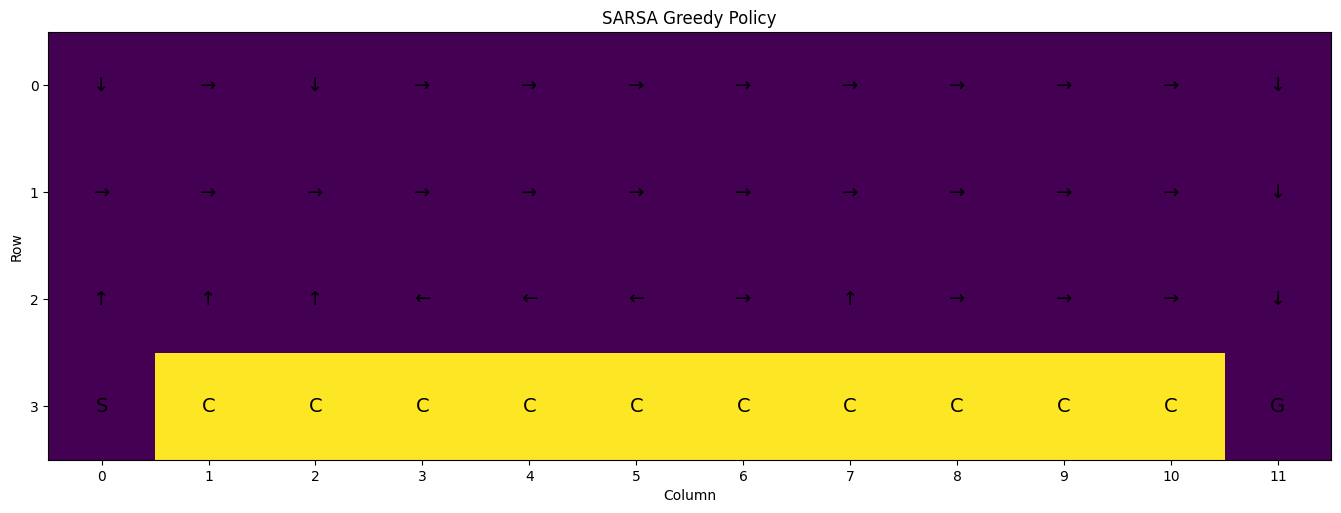

In [19]:
def plot_policy_grid(grid, title):
    background = np.zeros((4, 12))
    background[3, 1:11] = 1.0
    plt.figure(figsize=(14, 5))
    plt.imshow(background, interpolation="nearest")
    for row in range(4):
        for column in range(12):
            plt.text(column, row, grid[row, column], ha="center", va="center", fontsize=14)
    plt.xticks(np.arange(12))
    plt.yticks(np.arange(4))
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.title(title)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

plot_policy_grid(sarsa_policy, "SARSA Greedy Policy")

## 28. Visualize the Q-learning policy

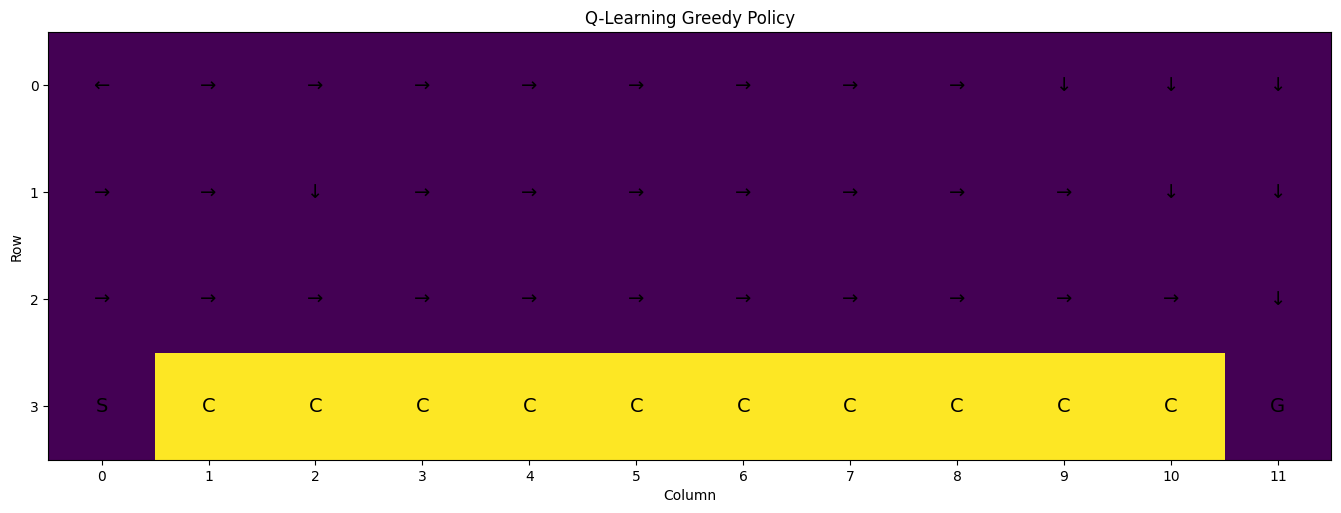

In [20]:
plot_policy_grid(q_learning_policy, "Q-Learning Greedy Policy")

## 29. Greedy evaluation

In [21]:
def evaluate_q_table(q_table, episodes=20, seed=10000, max_steps=1000):
    env = gym.make(ENV_ID, is_slippery=False)
    records = []
    for episode in range(episodes):
        state, info = env.reset(seed=seed + episode)
        total_reward = 0.0
        episode_length = 0
        cliff_falls = 0
        done = False
        while not done and episode_length < max_steps:
            action = int(np.argmax(q_table[state]))
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += reward
            episode_length += 1
            if reward == -100:
                cliff_falls += 1
            state = next_state
        records.append({"episode": episode + 1, "reward": total_reward, "length": episode_length, "cliff_falls": cliff_falls, "reached_goal": done})
    env.close()
    return pd.DataFrame(records)

In [22]:
sarsa_eval = evaluate_q_table(sarsa_q_table)
q_learning_eval = evaluate_q_table(q_learning_q_table)
print("SARSA evaluation")
display(sarsa_eval)
print("Q-learning evaluation")
display(q_learning_eval)

SARSA evaluation


,episode,reward,length,cliff_falls,reached_goal
0,1,-15.0,15,0,True
1,2,-15.0,15,0,True
2,3,-15.0,15,0,True
3,4,-15.0,15,0,True
4,5,-15.0,15,0,True
5,6,-15.0,15,0,True
6,7,-15.0,15,0,True
7,8,-15.0,15,0,True
8,9,-15.0,15,0,True
9,10,-15.0,15,0,True


Q-learning evaluation


,episode,reward,length,cliff_falls,reached_goal
0,1,-13.0,13,0,True
1,2,-13.0,13,0,True
2,3,-13.0,13,0,True
3,4,-13.0,13,0,True
4,5,-13.0,13,0,True
5,6,-13.0,13,0,True
6,7,-13.0,13,0,True
7,8,-13.0,13,0,True
8,9,-13.0,13,0,True
9,10,-13.0,13,0,True


## 30. Evaluation summary

In [23]:
summary_df = pd.DataFrame({
    "Policy": ["Random", "SARSA", "Q-Learning"],
    "Mean Reward": [random_history["reward"].mean(), sarsa_eval["reward"].mean(), q_learning_eval["reward"].mean()],
    "Mean Length": [random_history["length"].mean(), sarsa_eval["length"].mean(), q_learning_eval["length"].mean()],
    "Mean Cliff Falls": [random_history["cliff_falls"].mean(), sarsa_eval["cliff_falls"].mean(), q_learning_eval["cliff_falls"].mean()]
})
display(summary_df)

,Policy,Mean Reward,Mean Length,Mean Cliff Falls
0,Random,-33980.24,3357.56,309.32
1,SARSA,-15.00,15.00,0.00
2,Q-Learning,-13.00,13.00,0.00


## 31. Mean evaluation reward comparison

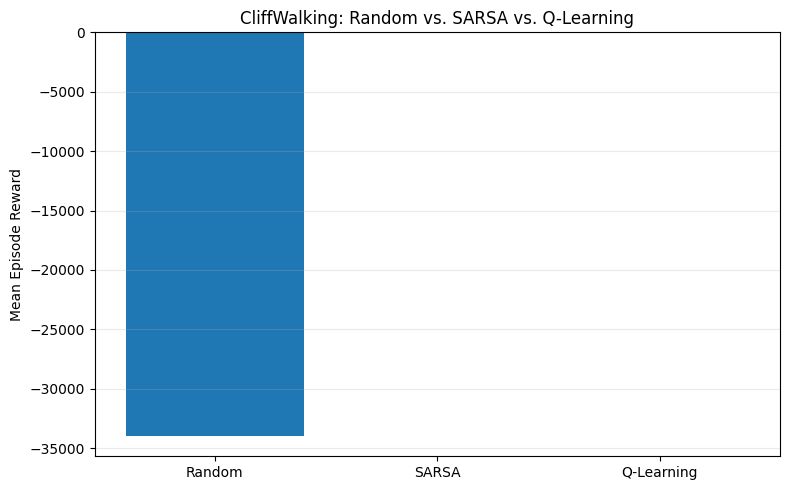

In [24]:
plt.figure(figsize=(8, 5))
plt.bar(summary_df["Policy"], summary_df["Mean Reward"])
plt.ylabel("Mean Episode Reward")
plt.title("CliffWalking: Random vs. SARSA vs. Q-Learning")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 32. Trace one greedy path

In [25]:
def trace_greedy_path(q_table, seed=20000, max_steps=100):
    env = gym.make(ENV_ID, is_slippery=False)
    state, info = env.reset(seed=seed)
    states = [state]
    actions = []
    rewards = []
    done = False
    while not done and len(actions) < max_steps:
        action = int(np.argmax(q_table[state]))
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        actions.append(action)
        rewards.append(reward)
        states.append(next_state)
        state = next_state
    env.close()
    return states, actions, rewards, done

In [26]:
sarsa_states, sarsa_actions, sarsa_path_rewards, sarsa_done = trace_greedy_path(sarsa_q_table)
q_learning_states, q_learning_actions, q_learning_path_rewards, q_learning_done = trace_greedy_path(q_learning_q_table)
print("SARSA path states:", sarsa_states)
print("SARSA path actions:", [ACTION_NAMES[action] for action in sarsa_actions])
print("SARSA path reward:", sum(sarsa_path_rewards))
print("SARSA reached goal:", sarsa_done)
print()
print("Q-learning path states:", q_learning_states)
print("Q-learning path actions:", [ACTION_NAMES[action] for action in q_learning_actions])
print("Q-learning path reward:", sum(q_learning_path_rewards))
print("Q-learning reached goal:", q_learning_done)

SARSA path states: [36, 24, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 35, 47]
SARSA path actions: ['Up', 'Up', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Down', 'Down']
SARSA path reward: -15
SARSA reached goal: True

Q-learning path states: [36, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 47]
Q-learning path actions: ['Up', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Down']
Q-learning path reward: -13
Q-learning reached goal: True


## 33. Visualize the SARSA greedy path

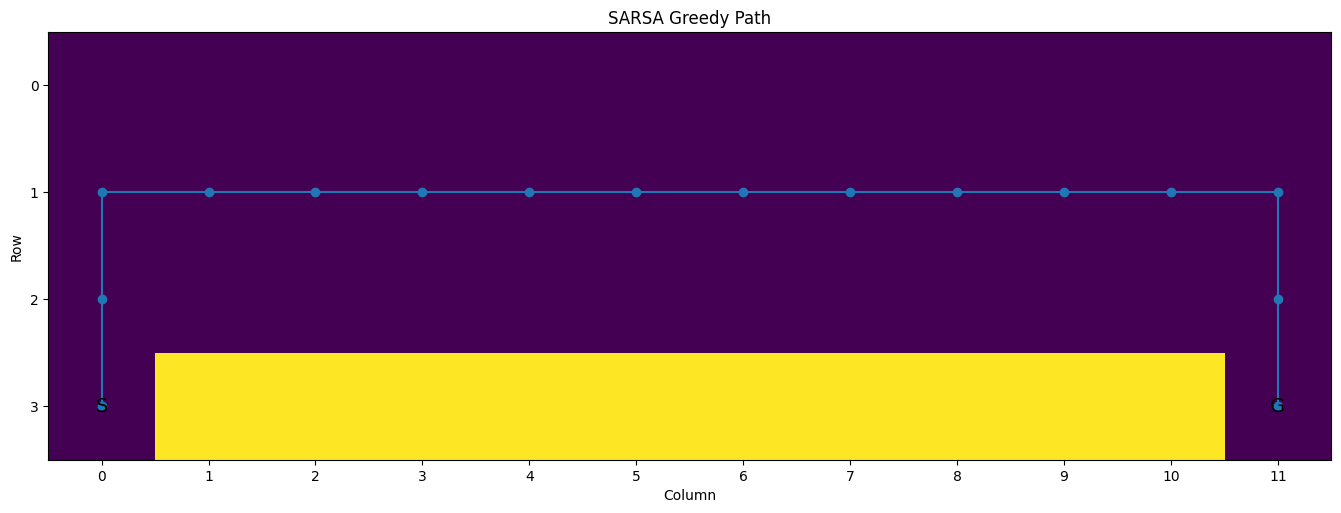

In [27]:
def plot_path(states, title):
    background = np.zeros((4, 12))
    background[3, 1:11] = 1.0
    coordinates = [np.unravel_index(state, (4, 12)) for state in states]
    rows = [coordinate[0] for coordinate in coordinates]
    columns = [coordinate[1] for coordinate in coordinates]
    plt.figure(figsize=(14, 5))
    plt.imshow(background, interpolation="nearest")
    plt.plot(columns, rows, marker="o")
    plt.text(0, 3, "S", ha="center", va="center", fontsize=14)
    plt.text(11, 3, "G", ha="center", va="center", fontsize=14)
    plt.xticks(np.arange(12))
    plt.yticks(np.arange(4))
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.title(title)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

plot_path(sarsa_states, "SARSA Greedy Path")

## 34. Visualize the Q-learning greedy path

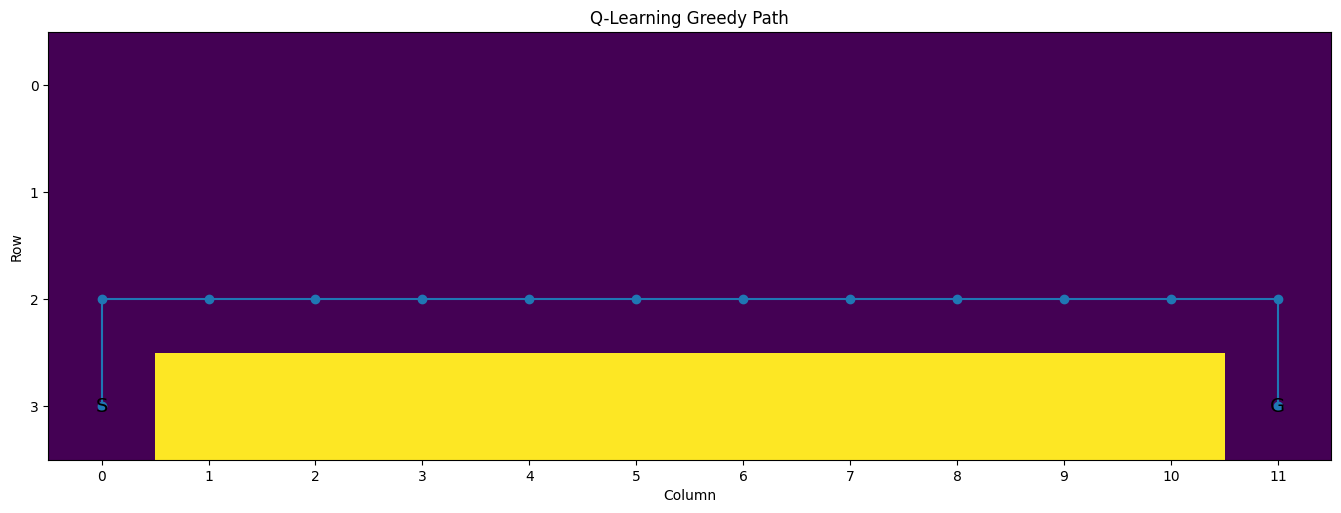

In [28]:
plot_path(q_learning_states, "Q-Learning Greedy Path")

## 35. Why the paths can differ

The Q-learning target assumes the next action will be greedy:

$$
\max_aQ(S_{t+1},a).
$$

Therefore it learns toward the best deterministic route even while its behavior policy is exploring.

SARSA evaluates the action that its epsilon-greedy behavior actually selects.

With a persistent:

$$
\epsilon=0.1,
$$

a position immediately beside the cliff carries additional risk because a random exploratory action can send the agent into the cliff.

This is why SARSA often learns a safer path while Q-learning often learns the shorter path close to the cliff.

## 36. Save the newly trained Q-tables

In [29]:
with open("sarsa_q_table.pkl", "wb") as file:
    pickle.dump(sarsa_q_table, file)
with open("q_learning_q_table.pkl", "wb") as file:
    pickle.dump(q_learning_q_table, file)
print("Saved sarsa_q_table.pkl")
print("Saved q_learning_q_table.pkl")

Saved sarsa_q_table.pkl
Saved q_learning_q_table.pkl


## 37. Optional: compare with the supplied saved Q-tables

The source project includes previously saved:

```text
sarsa_q_table.pkl
q_learning_q_table.pkl
```

If those files are placed in the same Colab working directory **before** this cell runs under different names such as:

```text
source_sarsa_q_table.pkl
source_q_learning_q_table.pkl
```

the next cell compares their greedy policies with the newly trained tables.

Exact Q-values are not expected to match because the original training scripts did not specify a random seed.

In [30]:
def compare_saved_table(filename, learned_table, label):
    if not os.path.exists(filename):
        print(label, "source table not found:", filename)
        return
    with open(filename, "rb") as file:
        source_table = pickle.load(file)
    same_actions = np.argmax(source_table, axis=1) == np.argmax(learned_table, axis=1)
    agreement = 100.0 * np.mean(same_actions)
    mean_absolute_difference = np.mean(np.abs(source_table - learned_table))
    print(label, "shape:", source_table.shape)
    print(label, "greedy-action agreement:", f"{agreement:.1f}%")
    print(label, "mean absolute Q-value difference:", f"{mean_absolute_difference:.4f}")

compare_saved_table("source_sarsa_q_table.pkl", sarsa_q_table, "SARSA")
compare_saved_table("source_q_learning_q_table.pkl", q_learning_q_table, "Q-Learning")

SARSA source table not found: source_sarsa_q_table.pkl
Q-Learning source table not found: source_q_learning_q_table.pkl


## 38. Evaluator note from the supplied source

The original evaluator loads the Q-learning table and evaluates with:

```python
action = policy(state)
```

where the default exploration value is zero.

Therefore the evaluation is greedy.

Its exploratory branch contains:

```python
np.random.randint(low=0, high=1)
```

which would only generate action `0`.

That line does not affect the supplied greedy evaluation because the branch is not entered when `explore=0.0`.

The portfolio evaluator above directly uses:

```python
np.argmax(q_table[state])
```

to make the greedy evaluation behavior explicit.

## 39. Create an evaluation animation

In [31]:
def make_cliff_frame(state, step, total_reward, algorithm):
    grid = np.zeros((4, 12))
    grid[3, 1:11] = 1.0
    row, column = np.unravel_index(state, (4, 12))
    figure = plt.figure(figsize=(10, 3.5))
    plt.imshow(grid, interpolation="nearest")
    plt.scatter([column], [row], s=180)
    plt.text(0, 3, "S", ha="center", va="center", fontsize=13)
    plt.text(11, 3, "G", ha="center", va="center", fontsize=13)
    plt.xticks(np.arange(12))
    plt.yticks(np.arange(4))
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.title(f"{algorithm} | Step {step} | Reward {total_reward:.0f}")
    plt.grid(False)
    plt.tight_layout()
    figure.canvas.draw()
    image = np.asarray(figure.canvas.buffer_rgba())[:, :, :3].copy()
    plt.close(figure)
    return image

In [32]:
def record_policy_video(q_table, filename, algorithm, seed=30000, fps=4, max_steps=100):
    env = gym.make(ENV_ID, is_slippery=False)
    state, info = env.reset(seed=seed)
    frames = []
    total_reward = 0.0
    step = 0
    done = False
    frames.append(make_cliff_frame(state, step, total_reward, algorithm))
    while not done and step < max_steps:
        action = int(np.argmax(q_table[state]))
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
        step += 1
        state = next_state
        frames.append(make_cliff_frame(state, step, total_reward, algorithm))
    env.close()
    imageio.mimsave(filename, frames, fps=fps)
    print("Saved:", filename)
    print("Total reward:", total_reward)
    print("Episode length:", step)
    return filename

In [33]:
q_learning_video = record_policy_video(q_learning_q_table, "cliffwalking_q_learning.mp4", "Q-Learning")
display(Video(q_learning_video, embed=True))

Saved: cliffwalking_q_learning.mp4
Total reward: -13.0
Episode length: 13


## 40. Source-faithful SARSA pseudocode

```text
Initialize Q(s,a) = 0

For each of 500 episodes:

    Reset environment

    Choose action A from S
    using epsilon-greedy policy

    Repeat until goal:

        Take action A

        Observe:
            reward R
            next state S'

        Choose next action A'
        from S'
        using epsilon-greedy policy

        target =
            R
            + gamma * Q(S', A')

        Q(S,A) =
            Q(S,A)
            + alpha
              * [target - Q(S,A)]

        S = S'
        A = A'
```

## 41. Source-faithful Q-learning pseudocode

```text
Initialize Q(s,a) = 0

For each of 500 episodes:

    Reset environment

    Repeat until goal:

        Choose action A from S
        using epsilon-greedy policy

        Take action A

        Observe:
            reward R
            next state S'

        Choose greedy next action:

            A* = argmax_a Q(S',a)

        target =
            R
            + gamma * Q(S', A*)

        Q(S,A) =
            Q(S,A)
            + alpha
              * [target - Q(S,A)]

        S = S'
```

## 42. SARSA and Q-learning in one view

| Property | SARSA | Q-learning |
|---|---|---|
| Learning type | TD control | TD control |
| Policy relation | On-policy | Off-policy |
| Behavior policy | $\epsilon$-greedy | $\epsilon$-greedy |
| Next value | $Q(S_{t+1},A_{t+1})$ | $\max_a Q(S_{t+1},a)$ |
| Learns about | Policy actually followed | Greedy target policy |
| CliffWalking tendency | Safer route | Shorter cliff-edge route |
| Q-table size | $48\times4$ | $48\times4$ |
| $\epsilon$ | 0.1 | 0.1 |
| $\alpha$ | 0.1 | 0.1 |
| $\gamma$ | 0.9 | 0.9 |
| Episodes | 500 | 500 |

## 43. Key takeaways

This demonstrates how two algorithms can interact with the same environment, use the same reward, state representation, action space, learning rate, discount factor, exploration rate, and number of training episodes, yet learn different control behavior because their update targets are different.

The key distinction is:

$$
\boxed{
\text{SARSA learns from the action actually selected}
}
$$

while:

$$
\boxed{
\text{Q-learning learns from the greedy next action}
}
$$

CliffWalking makes this difference visible because exploration near the cliff is costly.

## References

1. Sutton, R. S., & Barto, A. G. *Reinforcement Learning: An Introduction*, 2nd ed. Cliff Walking example.
2. Gymnasium documentation, CliffWalking.
3. Supplied project files: `sarsa.py`, `q_learning.py`, `random_agent.py`, `evaluator.py`, `cv_show.py`, and the saved Q-tables.